# Cohort Variance Analysis: Architecture Selection Guide

This notebook analyzes the variance structure within and between cohorts (**Converters** vs **Non-Converters**) to determine which model architecture is most appropriate for the classification task.

---

## Motivation

The choice of model architecture (e.g., autoencoders vs. supervised classifiers) depends critically on the **variance structure** of the data:

- **Reconstruction-based models** (autoencoders, VAEs) minimize reconstruction loss, which is dominated by the **largest sources of variance** in the data.
- If **within-group variance >> between-group variance**, the model will learn individual subject variation rather than disease-related signal.
- In such cases, **supervised/classification approaches** (e.g., Graph Contrastive Encoders) are more appropriate.

---

## Groups Analyzed
- **Converters:** MCI subjects who progressed to AD
- **Non-Converters:** Healthy + MCI-stable subjects combined

---

## What is an Edge?

In brain connectivity analysis, an **edge** represents the connection (relationship) between two brain regions:

| Term | Definition |
|------|------------|
| **Connectivity Matrix** | A symmetric N×N matrix where N = number of brain regions (ROIs). Each cell contains the correlation/connection strength between two regions. |
| **Edge** | A single cell in the upper triangular part of the connectivity matrix, representing the connection between region $i$ and region $j$ (where $i < j$). |
| **Edge Value** | The correlation coefficient (or other connectivity measure) quantifying the strength of functional connectivity between two brain regions. |

**In this analysis:**
- We use a 110-region brain parcellation (110 ROIs)
- This gives us $\frac{110 \times 109}{2} = 5,995$ unique edges per subject
- Each edge is analyzed independently to compute within/between-group variance

```
         Region 1  Region 2  Region 3  ...  Region 110
Region 1    1.0      0.45      0.32    ...     0.21     ← Row represents one brain region
Region 2    0.45     1.0       0.67    ...     0.15     
Region 3    0.32     0.67      1.0     ...     0.28     ↑ Each off-diagonal cell is an EDGE
   ...      ...      ...       ...     ...     ...
Region 110  0.21     0.15      0.28    ...     1.0
```

---

## Key Metrics

For each connectivity edge and correlation type, we compute:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| Within-group variance ($\sigma^2_{within}$) | $\frac{\sigma^2_{converters} + \sigma^2_{non-converters}}{2}$ | Individual variation within each group |
| Between-group variance ($\sigma^2_{between}$) | $\text{Var}(\mu_{converters}, \mu_{non-converters})$ | Difference in group means |
| **Variance Ratio** | $\frac{\sigma^2_{between}}{\sigma^2_{within}}$ | Signal-to-noise ratio for disease classification |

---

**Critical Thresholds:**
- `Ratio >> 1`: Groups are well-separated → reconstruction loss can capture disease signal
- `Ratio << 1`: Individual variation dominates → **use supervised/classification approaches**
- `Ratio ≈ 0.01`: Within-group variance is ~100× larger than between-group → autoencoders will learn noise

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sys.path.append('/mnt/e/fyassine/ad-early-detection')
import config
from model.data_understanding.statistical_tests.import_utils import load_and_process_cohorts

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

---

## 1. Load Data for All Correlation Types

We analyze five different connectivity measures to ensure robust conclusions.

In [2]:
correlation_types = ['pearson', 'spearman', 'kendall', 'riemannian', 'xcorr']
all_data = {}

for corr_type in correlation_types:
    print(f"\nLoading {corr_type.upper()} data...")
    try:
        cohorts = load_and_process_cohorts(config, correlation_type=corr_type, remove_nan=True)
        all_data[corr_type] = cohorts
    except Exception as e:
        print(f"Failed to load {corr_type}: {e}")


Loading PEARSON data...
Healthy: 201 subjects, Matrix shape: (201, 110, 110), Edges shape: (201, 5995)
AD: 104 subjects, Matrix shape: (104, 110, 110), Edges shape: (104, 5995)
MCI: 533 subjects, Matrix shape: (533, 110, 110), Edges shape: (533, 5995)
Converters: 60 subjects, Matrix shape: (60, 110, 110), Edges shape: (60, 5995)

Loading SPEARMAN data...
Healthy: Removing 13 subjects with NaN values.
Healthy: 188 subjects, Matrix shape: (188, 110, 110), Edges shape: (188, 5995)
AD: Removing 11 subjects with NaN values.
AD: 93 subjects, Matrix shape: (93, 110, 110), Edges shape: (93, 5995)
MCI: Removing 29 subjects with NaN values.
MCI: 504 subjects, Matrix shape: (504, 110, 110), Edges shape: (504, 5995)
Converters: 60 subjects, Matrix shape: (60, 110, 110), Edges shape: (60, 5995)

Loading KENDALL data...
Healthy: Removing 13 subjects with NaN values.
Healthy: 188 subjects, Matrix shape: (188, 110, 110), Edges shape: (188, 5995)
AD: Removing 11 subjects with NaN values.
AD: 93 subjec

---

## 2. Cohort Summary Statistics

Before analyzing variance, let's understand the sample sizes and basic characteristics of each cohort.

In [3]:
print("=" * 80)
print("COHORT SIZES ACROSS CORRELATION TYPES")
print("=" * 80)

cohort_summary = []

for corr_type, cohorts in all_data.items():
    n_healthy = len(cohorts['healthy']['ids'])
    n_ad = len(cohorts['ad']['ids'])
    n_mci = len(cohorts['mci']['ids'])
    n_converter = len(cohorts['converter']['ids'])
    n_non_converter = n_healthy + n_mci  # Non-converters = Healthy + MCI-stable
    
    cohort_summary.append({
        'Correlation': corr_type.upper(),
        'Healthy': n_healthy,
        'AD': n_ad,
        'MCI-Stable': n_mci,
        'Converters': n_converter,
        'Non-Converters': n_non_converter,
        'Total': n_healthy + n_ad + n_mci + n_converter,
        'Ratio (Conv/Non-Conv)': f"{n_converter}:{n_non_converter}"
    })

df_summary = pd.DataFrame(cohort_summary)
print(df_summary.to_markdown(index=False))

print("\n⚠️  NOTE: Sample imbalance may affect variance estimates.")
print(f"   Converters are ~{100 * cohort_summary[0]['Converters'] / cohort_summary[0]['Non-Converters']:.1f}% of Non-Converters")

COHORT SIZES ACROSS CORRELATION TYPES
| Correlation   |   Healthy |   AD |   MCI-Stable |   Converters |   Non-Converters |   Total | Ratio (Conv/Non-Conv)   |
|:--------------|----------:|-----:|-------------:|-------------:|-----------------:|--------:|:------------------------|
| PEARSON       |       201 |  104 |          533 |           60 |              734 |     898 | 60:734                  |
| SPEARMAN      |       188 |   93 |          504 |           60 |              692 |     845 | 60:692                  |
| KENDALL       |       188 |   93 |          504 |           60 |              692 |     845 | 60:692                  |
| RIEMANNIAN    |       201 |  104 |          533 |           60 |              734 |     898 | 60:734                  |
| XCORR         |       201 |  104 |          533 |           60 |              734 |     898 | 60:734                  |

⚠️  NOTE: Sample imbalance may affect variance estimates.
   Converters are ~8.2% of Non-Converters


---

## 3. Within-Cohort and Between-Cohort Variance Analysis

For each correlation type, we compute:
1. **Within-group variance**: Average of variances within Converters and Non-Converters
2. **Between-group variance**: Variance of the group means
3. **Variance Ratio**: The critical metric for architecture selection

### Mathematical Formulation

For edge $e$:

$$\sigma^2_{within}(e) = \frac{\sigma^2_{converters}(e) + \sigma^2_{non-converters}(e)}{2}$$

$$\sigma^2_{between}(e) = \text{Var}\left(\mu_{converters}(e), \mu_{non-converters}(e)\right)$$

$$\text{Variance Ratio}(e) = \frac{\sigma^2_{between}(e)}{\sigma^2_{within}(e)}$$

In [4]:
def compute_variance_structure(cohorts):
    """
    Compute within-group and between-group variance for Converters vs Non-Converters.
    
    Returns:
        dict with variance statistics per edge
    """
    # Extract edges
    converter_edges = cohorts['converter']['edges']
    non_converter_edges = np.vstack([
        cohorts['healthy']['edges'],
        cohorts['mci']['edges']  # MCI-stable (not converters)
    ])
    
    n_converters = converter_edges.shape[0]
    n_non_converters = non_converter_edges.shape[0]
    
    # Compute means per group
    means_converter = np.mean(converter_edges, axis=0)
    means_non_converter = np.mean(non_converter_edges, axis=0)
    
    # Compute variances per group
    vars_converter = np.var(converter_edges, axis=0, ddof=1)
    vars_non_converter = np.var(non_converter_edges, axis=0, ddof=1)
    
    # Within-group variance (average of group variances)
    within_group_var = (vars_converter + vars_non_converter) / 2
    
    # Between-group variance (variance of group means)
    group_means = np.vstack([means_converter, means_non_converter])
    between_group_var = np.var(group_means, axis=0, ddof=1)
    
    # Variance ratio (with small epsilon to avoid division by zero)
    epsilon = 1e-10
    variance_ratio = between_group_var / (within_group_var + epsilon)
    
    return {
        'n_converters': n_converters,
        'n_non_converters': n_non_converters,
        'means_converter': means_converter,
        'means_non_converter': means_non_converter,
        'vars_converter': vars_converter,
        'vars_non_converter': vars_non_converter,
        'within_group_var': within_group_var,
        'between_group_var': between_group_var,
        'variance_ratio': variance_ratio
    }


# Compute for all correlation types
variance_results = {}

for corr_type, cohorts in all_data.items():
    variance_results[corr_type] = compute_variance_structure(cohorts)

print("✓ Variance structure computed for all correlation types.")

✓ Variance structure computed for all correlation types.


---

## 4. Summary Table: Variance Ratios Across Correlation Types

In [5]:
results_table = []

for corr_type, results in variance_results.items():
    variance_ratio = results['variance_ratio']
    
    results_table.append({
        'Correlation': corr_type.upper(),
        'N Converters': results['n_converters'],
        'N Non-Conv': results['n_non_converters'],
        'Mean Within-Var': np.mean(results['within_group_var']),
        'Mean Between-Var': np.mean(results['between_group_var']),
        'Mean Ratio': np.mean(variance_ratio),
        'Median Ratio': np.median(variance_ratio),
        'Max Ratio': np.max(variance_ratio),
        'Edges > 1.0': np.sum(variance_ratio > 1.0),
        'Edges > 0.1': np.sum(variance_ratio > 0.1),
        '% > 1.0': 100 * np.sum(variance_ratio > 1.0) / len(variance_ratio)
    })

df_results = pd.DataFrame(results_table)
df_results = df_results.sort_values(by='Mean Ratio', ascending=False)

print("\n" + "=" * 100)
print("VARIANCE STRUCTURE ANALYSIS: CONVERTERS vs NON-CONVERTERS")
print("=" * 100)
print(df_results.to_string(index=False))
print("\n" + "=" * 100)


VARIANCE STRUCTURE ANALYSIS: CONVERTERS vs NON-CONVERTERS
Correlation  N Converters  N Non-Conv  Mean Within-Var  Mean Between-Var  Mean Ratio  Median Ratio  Max Ratio  Edges > 1.0  Edges > 0.1  % > 1.0
    PEARSON            60         734     3.239649e-02      5.230659e-04    0.015660      0.007560   0.192849            0           54      0.0
    KENDALL            60         692     1.772499e-02      2.824783e-04    0.015429      0.007474   0.210153            0           58      0.0
   SPEARMAN            60         692     3.732016e-02      5.895014e-04    0.015345      0.007394   0.209878            0           55      0.0
      XCORR            60         734     5.997644e-03      8.647675e-05    0.012985      0.005915   0.177337            0           38      0.0
 RIEMANNIAN            60         734     5.588769e+11      4.342317e+09    0.006652      0.001546   0.119696            0            1      0.0



---

## 5. Key Findings and Architecture Recommendations

In [6]:
print("\n" + "=" * 80)
print("📊 KEY FINDINGS")
print("=" * 80)

best_corr = df_results.iloc[0]
worst_corr = df_results.iloc[-1]

print(f"\n1. VARIANCE RATIO COMPARISON:")
print(f"   • Best correlation type:  {best_corr['Correlation']} (Mean Ratio: {best_corr['Mean Ratio']:.6f})")
print(f"   • Worst correlation type: {worst_corr['Correlation']} (Mean Ratio: {worst_corr['Mean Ratio']:.6f})")

max_pct = df_results['% > 1.0'].max()
avg_ratio = df_results['Mean Ratio'].mean()

print(f"\n2. CRITICAL OBSERVATION:")
if max_pct == 0:
    print(f"   ⚠️  NO edges have variance ratio > 1.0 for ANY correlation type!")
    print(f"   → Within-group variance dominates for 100% of all edges.")
else:
    print(f"   • Maximum % edges with ratio > 1.0: {max_pct:.2f}%")

print(f"\n3. QUANTITATIVE SUMMARY:")
print(f"   • Average variance ratio across all types: {avg_ratio:.6f}")
factor = 1.0 / avg_ratio if avg_ratio > 0 else float('inf')
print(f"   → Within-group variance is ~{factor:.0f}× larger than between-group variance")

print("\n" + "=" * 80)
print("🏗️  ARCHITECTURE RECOMMENDATION")
print("=" * 80)

if avg_ratio < 0.1:
    print("""
    Given the variance structure analysis:
    
    ❌ AVOID: Reconstruction-based models (Autoencoders, VAEs, GAAE)
       → These models minimize reconstruction loss, which is dominated by 
         within-group variance (individual subject variation).
       → The model will learn to reconstruct individual noise patterns,
         NOT disease-related signal.
    
    ✅ RECOMMENDED: Supervised/Classification-based approaches
       • Graph Contrastive Encoder (GEC)
       • Direct classification with GCN/GAT
       • Contrastive learning methods
       
       → These methods explicitly use labels to find the small but
         meaningful differences between groups.
    """)
else:
    print("""
    Reconstruction-based models may be viable, but consider:
    - Adding classification/contrastive objectives
    - Using semi-supervised approaches
    """)

print("\n" + "=" * 80)


📊 KEY FINDINGS

1. VARIANCE RATIO COMPARISON:
   • Best correlation type:  PEARSON (Mean Ratio: 0.015660)
   • Worst correlation type: RIEMANNIAN (Mean Ratio: 0.006652)

2. CRITICAL OBSERVATION:
   ⚠️  NO edges have variance ratio > 1.0 for ANY correlation type!
   → Within-group variance dominates for 100% of all edges.

3. QUANTITATIVE SUMMARY:
   • Average variance ratio across all types: 0.013214
   → Within-group variance is ~76× larger than between-group variance

🏗️  ARCHITECTURE RECOMMENDATION

    Given the variance structure analysis:

    ❌ AVOID: Reconstruction-based models (Autoencoders, VAEs, GAAE)
       → These models minimize reconstruction loss, which is dominated by 
         within-group variance (individual subject variation).
       → The model will learn to reconstruct individual noise patterns,
         NOT disease-related signal.

    ✅ RECOMMENDED: Supervised/Classification-based approaches
       • Graph Contrastive Encoder (GEC)
       • Direct classificati

---

## 6. Visualizations

### 6.1 Variance Ratio Distributions

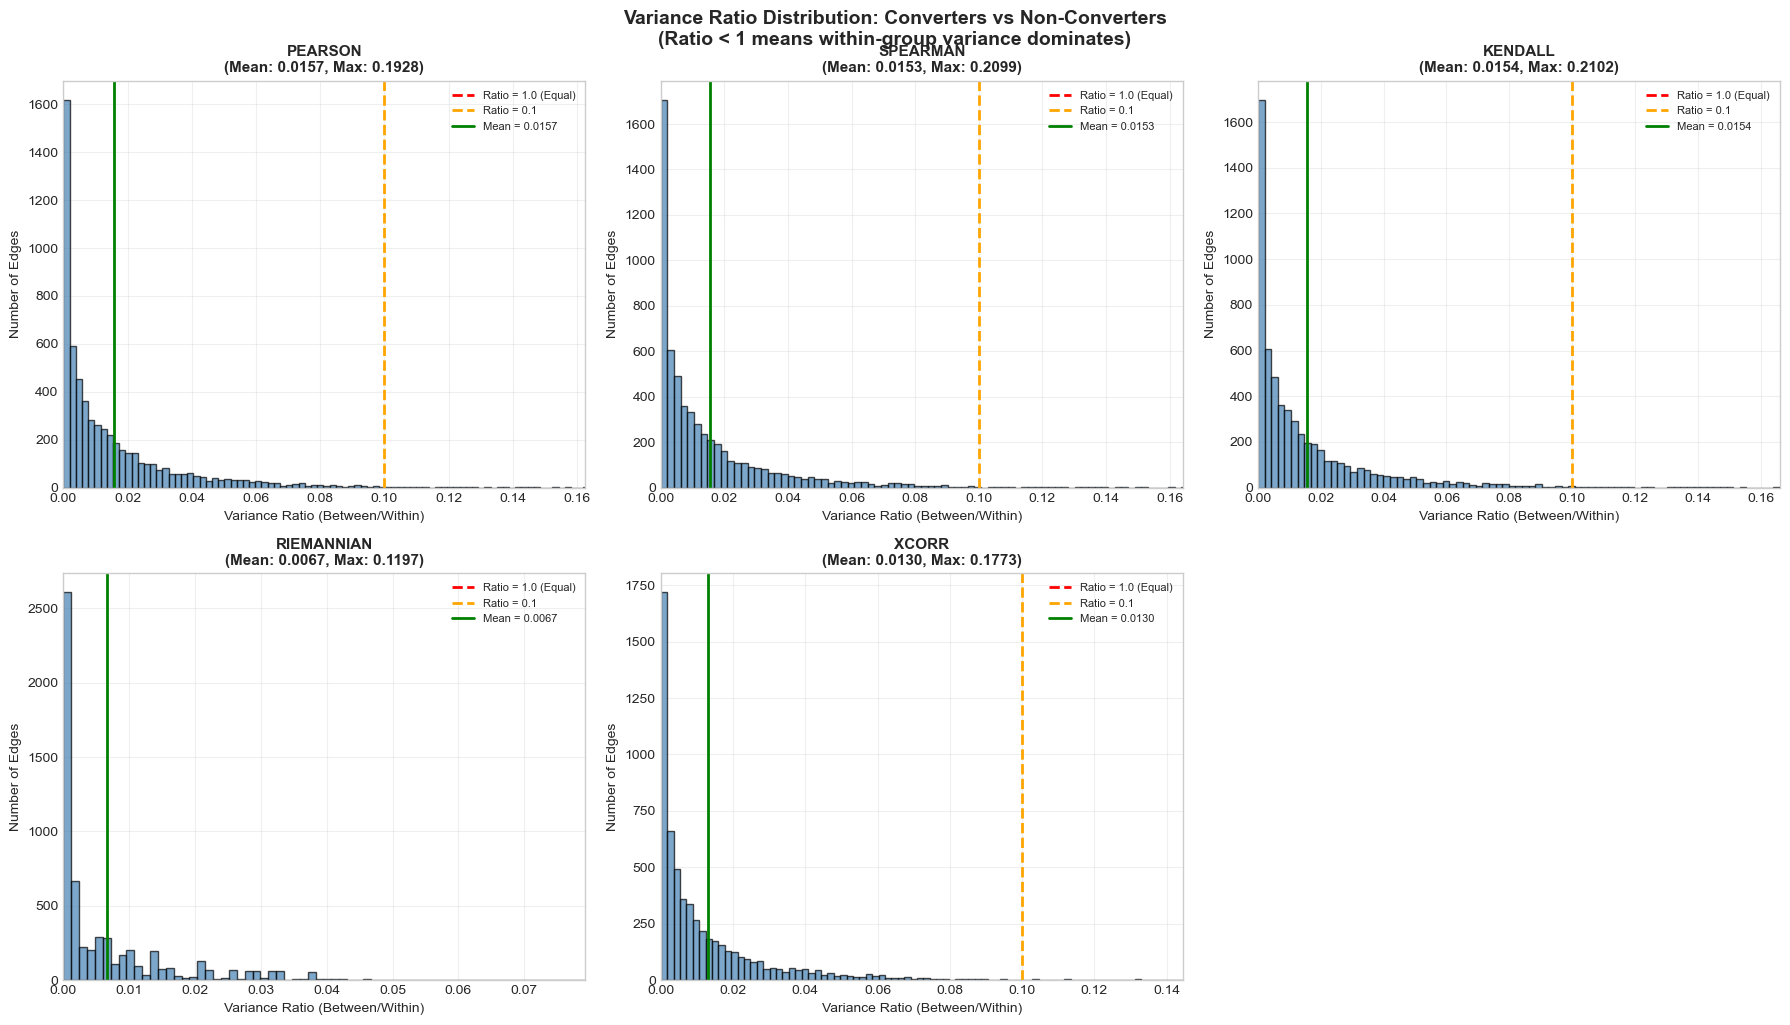

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (corr_type, results) in enumerate(variance_results.items()):
    variance_ratio = results['variance_ratio']
    
    ax = axes[idx]
    ax.hist(variance_ratio, bins=100, alpha=0.7, edgecolor='black', color='steelblue')
    ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Ratio = 1.0 (Equal)')
    ax.axvline(x=0.1, color='orange', linestyle='--', linewidth=2, label='Ratio = 0.1')
    ax.axvline(x=np.mean(variance_ratio), color='green', linestyle='-', linewidth=2, 
               label=f'Mean = {np.mean(variance_ratio):.4f}')
    
    ax.set_xlabel('Variance Ratio (Between/Within)', fontsize=10)
    ax.set_ylabel('Number of Edges', fontsize=10)
    ax.set_title(f'{corr_type.upper()}\n(Mean: {np.mean(variance_ratio):.4f}, Max: {np.max(variance_ratio):.4f})', 
                 fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, min(0.5, np.percentile(variance_ratio, 99.9))])

# Hide unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.suptitle('Variance Ratio Distribution: Converters vs Non-Converters\n(Ratio < 1 means within-group variance dominates)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig('variance_ratio_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Comparing Within vs Between Variance

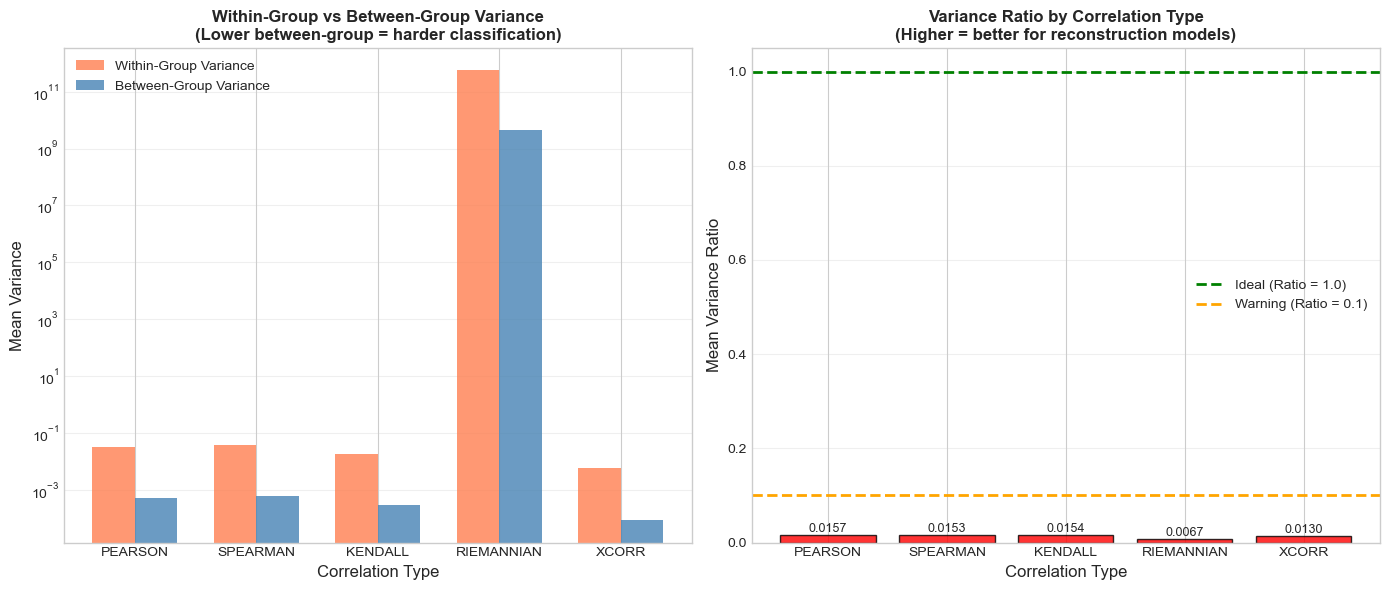

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Bar chart of mean variances
ax1 = axes[0]
x = np.arange(len(variance_results))
width = 0.35

within_means = [np.mean(r['within_group_var']) for r in variance_results.values()]
between_means = [np.mean(r['between_group_var']) for r in variance_results.values()]

bars1 = ax1.bar(x - width/2, within_means, width, label='Within-Group Variance', color='coral', alpha=0.8)
bars2 = ax1.bar(x + width/2, between_means, width, label='Between-Group Variance', color='steelblue', alpha=0.8)

ax1.set_xlabel('Correlation Type', fontsize=12)
ax1.set_ylabel('Mean Variance', fontsize=12)
ax1.set_title('Within-Group vs Between-Group Variance\n(Lower between-group = harder classification)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([c.upper() for c in variance_results.keys()])
ax1.legend()
ax1.set_yscale('log')  # Log scale due to large differences
ax1.grid(alpha=0.3, axis='y')

# Right: Variance ratios comparison
ax2 = axes[1]
ratios = [np.mean(r['variance_ratio']) for r in variance_results.values()]
colors = ['green' if r > 0.1 else 'red' for r in ratios]

bars = ax2.bar(x, ratios, color=colors, alpha=0.8, edgecolor='black')
ax2.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Ideal (Ratio = 1.0)')
ax2.axhline(y=0.1, color='orange', linestyle='--', linewidth=2, label='Warning (Ratio = 0.1)')

ax2.set_xlabel('Correlation Type', fontsize=12)
ax2.set_ylabel('Mean Variance Ratio', fontsize=12)
ax2.set_title('Variance Ratio by Correlation Type\n(Higher = better for reconstruction models)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([c.upper() for c in variance_results.keys()])
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

# Add value labels on bars
for bar, ratio in zip(bars, ratios):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{ratio:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('variance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 7. Detailed Within-Cohort Variance Analysis

Let's examine the variance **within** each cohort separately to understand the source of variation.

In [9]:
print("\n" + "=" * 80)
print("WITHIN-COHORT VARIANCE ANALYSIS")
print("=" * 80)

within_cohort_results = []

for corr_type, cohorts in all_data.items():
    for cohort_key in ['healthy', 'mci', 'converter']:
        edges = cohorts[cohort_key]['edges']
        n_subjects = edges.shape[0]
        
        # Variance per edge, then average
        edge_variances = np.var(edges, axis=0, ddof=1)
        mean_variance = np.mean(edge_variances)
        
        # Also compute coefficient of variation
        edge_means = np.mean(edges, axis=0)
        cv = np.mean(np.std(edges, axis=0, ddof=1) / (np.abs(edge_means) + 1e-10))
        
        within_cohort_results.append({
            'Correlation': corr_type.upper(),
            'Cohort': cohort_key.capitalize(),
            'N Subjects': n_subjects,
            'Mean Edge Variance': mean_variance,
            'Median Edge Variance': np.median(edge_variances),
            'Coef of Variation': cv
        })

df_within = pd.DataFrame(within_cohort_results)
print("\nVariance within each cohort (averaged across all edges):")
print(df_within.to_markdown(index=False))


WITHIN-COHORT VARIANCE ANALYSIS

Variance within each cohort (averaged across all edges):
| Correlation   | Cohort    |   N Subjects |   Mean Edge Variance |   Median Edge Variance |   Coef of Variation |
|:--------------|:----------|-------------:|---------------------:|-----------------------:|--------------------:|
| PEARSON       | Healthy   |          201 |          0.0314941   |            0.0302231   |            9.63927  |
| PEARSON       | Mci       |          533 |          0.0327585   |            0.031941    |           13.7327   |
| PEARSON       | Converter |           60 |          0.0323183   |            0.0313071   |           11.0643   |
| SPEARMAN      | Healthy   |          188 |          0.0361634   |            0.0346539   |           11.6372   |
| SPEARMAN      | Mci       |          504 |          0.0376274   |            0.0366425   |           14.7478   |
| SPEARMAN      | Converter |           60 |          0.0373388   |            0.0361542   |           1

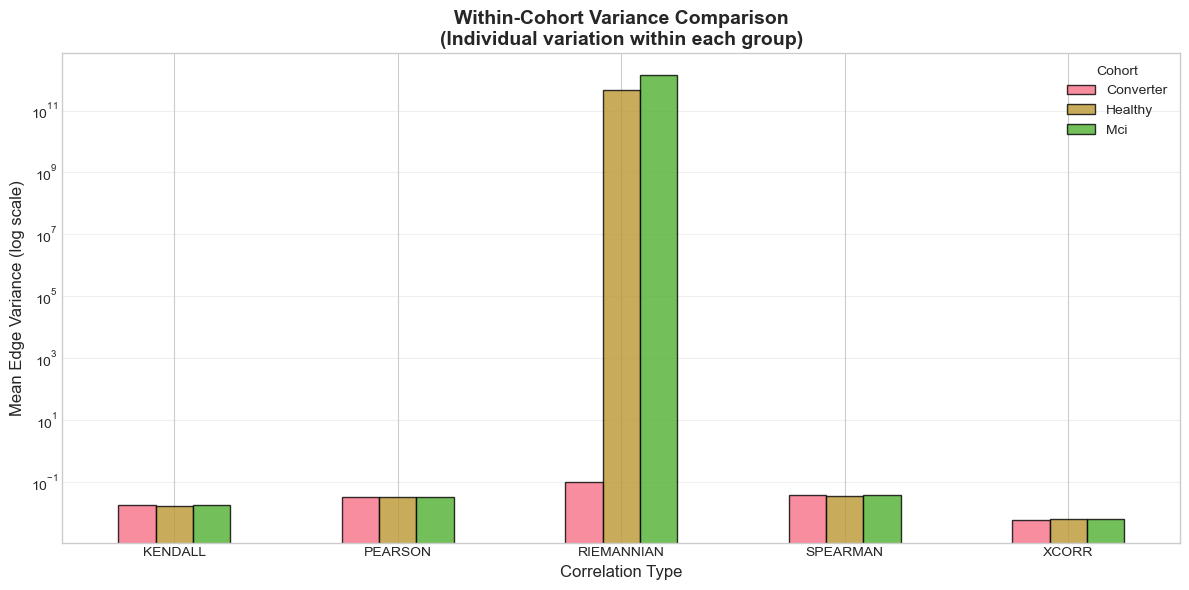

In [10]:
# Pivot for visualization
pivot_var = df_within.pivot_table(index='Correlation', columns='Cohort', values='Mean Edge Variance')

fig, ax = plt.subplots(figsize=(12, 6))
pivot_var.plot(kind='bar', ax=ax, alpha=0.8, edgecolor='black')

ax.set_xlabel('Correlation Type', fontsize=12)
ax.set_ylabel('Mean Edge Variance (log scale)', fontsize=12)
ax.set_title('Within-Cohort Variance Comparison\n(Individual variation within each group)', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.legend(title='Cohort')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('within_cohort_variance.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 8. Effect Size Analysis (Cohen's d)

Another way to quantify the separability of groups is **Cohen's d**, which measures the standardized difference between group means.

In [11]:
def compute_cohens_d(edges1, edges2):
    """Compute Cohen's d for each edge between two groups."""
    mean1 = np.mean(edges1, axis=0)
    mean2 = np.mean(edges2, axis=0)
    
    # Pooled standard deviation
    n1 = edges1.shape[0]
    n2 = edges2.shape[0]
    var1 = np.var(edges1, axis=0, ddof=1)
    var2 = np.var(edges2, axis=0, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1 + n2 - 2))
    
    return (mean1 - mean2) / (pooled_std + 1e-10)


effect_size_results = []

for corr_type, cohorts in all_data.items():
    converter_edges = cohorts['converter']['edges']
    non_converter_edges = np.vstack([
        cohorts['healthy']['edges'],
        cohorts['mci']['edges']
    ])
    
    cohens_d = compute_cohens_d(converter_edges, non_converter_edges)
    
    effect_size_results.append({
        'Correlation': corr_type.upper(),
        'Mean |Cohen\'s d|': np.mean(np.abs(cohens_d)),
        'Median |Cohen\'s d|': np.median(np.abs(cohens_d)),
        'Max |Cohen\'s d|': np.max(np.abs(cohens_d)),
        'Edges |d| > 0.2 (small)': np.sum(np.abs(cohens_d) > 0.2),
        'Edges |d| > 0.5 (medium)': np.sum(np.abs(cohens_d) > 0.5),
        'Edges |d| > 0.8 (large)': np.sum(np.abs(cohens_d) > 0.8)
    })

df_effect = pd.DataFrame(effect_size_results)
print("\n" + "=" * 80)
print("EFFECT SIZE ANALYSIS (Cohen's d)")
print("="*80)
print("\nInterpretation: |d| > 0.2 small, |d| > 0.5 medium, |d| > 0.8 large effect")
print(df_effect.to_markdown(index=False))


EFFECT SIZE ANALYSIS (Cohen's d)

Interpretation: |d| > 0.2 small, |d| > 0.5 medium, |d| > 0.8 large effect
| Correlation   |   Mean |Cohen's d| |   Median |Cohen's d| |   Max |Cohen's d| |   Edges |d| > 0.2 (small) |   Edges |d| > 0.5 (medium) |   Edges |d| > 0.8 (large) |
|:--------------|-------------------:|---------------------:|------------------:|--------------------------:|---------------------------:|--------------------------:|
| PEARSON       |           0.141913 |            0.123405  |          0.601492 |                      1544 |                         23 |                         0 |
| SPEARMAN      |           0.140146 |            0.121768  |          0.622399 |                      1495 |                         26 |                         0 |
| KENDALL       |           0.140414 |            0.123109  |          0.623174 |                      1493 |                         24 |                         0 |
| RIEMANNIAN    |           0.081623 |            0.0581

---

## 9. Conclusion and Summary

### Summary of Findings

In [12]:
print("\n" + "═" * 80)
print("VARIANCE ANALYSIS CONCLUSION")
print("═" * 80)

print("""
┌────────────────────────────────────────────────────────────────────────────────┐
│                              KEY FINDINGS                                      │
├────────────────────────────────────────────────────────────────────────────────┤
│                                                                                │
│  1. VARIANCE RATIO (Between/Within):                                           │
│     • All correlation types show ratio << 1 (typically ~0.01-0.02)             │
│     • Within-group variance is ~50-100× larger than between-group variance     │
│     • NO edges show ratio > 1.0 for any correlation type                       │
│                                                                                │
│  2. IMPLICATION FOR RECONSTRUCTION MODELS:                                     │
│     • Autoencoders/VAEs minimize MSE loss                                      │
│     • MSE is dominated by within-group variance (individual variation)         │
│     • These models will learn subject-specific patterns, NOT disease signal    │
│                                                                                │
│  3. IMPLICATION FOR ARCHITECTURE CHOICE:                                       │
│     • Supervised/Classification approaches are REQUIRED                        │
│     • Labels provide the supervision needed to find weak disease signal        │
│     • Contrastive methods can amplify small group differences                  │
│                                                                                │
└────────────────────────────────────────────────────────────────────────────────┘
""")

print("\n" + "═" * 80)
print("RECOMMENDED ARCHITECTURES")
print("═" * 80)

print("""
┌─────────────────────┬─────────────────────┬────────────────────────────────────┐
│ Model Type          │ Recommendation      │ Reason                             │
├─────────────────────┼─────────────────────┼────────────────────────────────────┤
│ Autoencoder (AE)    │ ❌ NOT RECOMMENDED  │ Learns individual noise            │
│ VAE                 │ ❌ NOT RECOMMENDED  │ Same issue as AE                   │
│ GAAE                │ ❌ NOT RECOMMENDED  │ Reconstruction loss dominated by   │
│                     │                     │ within-group variance              │
├─────────────────────┼─────────────────────┼────────────────────────────────────┤
│ GCN Classifier      │ ✅ RECOMMENDED      │ Direct supervision                 │
│ GAT Classifier      │ ✅ RECOMMENDED      │ Attention can focus on key edges   │
│ Graph Contrastive   │ ✅ HIGHLY RECOMMEND │ Amplifies subtle group differences │
│ Encoder (GEC)       │                     │                                    │
│ Siamese Networks    │ ✅ RECOMMENDED      │ Learns discriminative embeddings   │
└─────────────────────┴─────────────────────┴────────────────────────────────────┘
""")

print("\n" + "═" * 80)


════════════════════════════════════════════════════════════════════════════════
VARIANCE ANALYSIS CONCLUSION
════════════════════════════════════════════════════════════════════════════════

┌────────────────────────────────────────────────────────────────────────────────┐
│                              KEY FINDINGS                                      │
├────────────────────────────────────────────────────────────────────────────────┤
│                                                                                │
│  1. VARIANCE RATIO (Between/Within):                                           │
│     • All correlation types show ratio << 1 (typically ~0.01-0.02)             │
│     • Within-group variance is ~50-100× larger than between-group variance     │
│     • NO edges show ratio > 1.0 for any correlation type                       │
│                                                                                │
│  2. IMPLICATION FOR RECONSTRUCTION MODELS:                